In [ ]:
import numpy as np
from matplotlib import pyplot as plt
"""Aufbau: 
	S. 50 in der Dr-Arbeit	
"""


In [8]:
"""
Bestimmung der Müller-Matrix einer Probe
========================================

Aufbau:

    Grüner Laser
         |
         v
   Polarisator P
         |
         v
       Probe
         |
         v
   Analysator A
         |
         v
   Photodetektor

Das Skript simuliert Messungen und rekonstruiert anschließend
die 4x4-Müller-Matrix der Probe.

Annahmen:
- grüner Laser: lambda = 532 nm
- monochromatisches Licht
- ideale lineare Polarisatoren
- Intensitätsdetektor
- keine Depolarisation durch die optischen Komponenten
- Jones-/Mueller-Koordinatensystem:
      S = [I, Q, U, V]^T

Wichtig:
Für die vollständige Müller-Matrix sind mehrere unabhängige
Polarisationszustände notwendig. Ein einzelnes P-A-Paar bei
90° reicht nicht aus.
"""

import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. Grundeinstellungen
# ============================================================

WAVELENGTH = 532e-9       # 532 nm, grüner Laser
LASER_POWER = 1.0         # normierte Laserleistung


# ============================================================
# 2. Stokes-Vektor des Lasers
# ============================================================

def laser_stokes():
    """
    Linear polarisiertes Laserlicht.

    Der Laser wird hier als vollständig linear polarisiert
    in horizontaler Richtung angenommen.

    S = [I, Q, U, V]
    """
	#Stokes Vektor, (Intensität, vertikale Lineare Polarisation, 45° Lineare Polarisation, Zirkulare Polarisation)T
    return np.array([
        LASER_POWER,
        LASER_POWER,
        0.0,
        0.0
    ])


# ============================================================
# 3. Müller-Matrix eines idealen linearen Polarisators
# ============================================================

def polarizer_matrix(angle_deg):
	"""
	Müller-Matrix eines idealen linearen Polarisators.

	angle_deg:
		Polarisationswinkel in Grad.

	Rückgabe:
		4x4 Müller-Matrix
	"""

	theta = np.deg2rad(angle_deg)

	c = np.cos(2 * theta)
	s = np.sin(2 * theta)
	#Generelle linear polarisierer Müller Matrix
	M = 0.5 * np.array([
		[1,  c,  s, 0],
		[c, c**2, c*s, 0],
		[s, c*s, s**2, 0],
		[0,  0,   0,  0]
	])

	return M


def retarder_matrix(theta, delta):
	c = np.cos(2*theta)
	s = np.sin(2*theta)
	cd = np.cos(delta)
	sd = np.sin(delta)

	M = np.array([
		[1,0,0,0],
		[0, c**2+s**2*cd, c*s*(1-cd), s*sd],
		[0, c*s*(1-cd), c**2*cd+s**2, -c*sd],
		[0, -s*sd, c*sd, cd],
	])
	return M


# ============================================================
# 4. Beispiel-Müller-Matrix einer Probe
# ============================================================

def example_sample_matrix():
    """
    Beispiel einer Proben-Müllermatrix.

    Diese Matrix dient ausschließlich zur Simulation.
    Später wird sie durch die tatsächlich gemessene
    Matrix ersetzt.

    Beispiel:
        teilweise polarisierende / anisotrope Probe
    """

    M = np.array([
        [0.80,  0.10,  0.05,  0.02],
        [0.08,  0.55,  0.10,  0.03],
        [0.04,  0.12,  0.45, -0.08],
        [0.01,  0.02,  0.10,  0.35]
    ])

    return M


# ============================================================
# 5. Messung simulieren
# ============================================================

def measure_intensity(sample_matrix,
                      polarizer_angle,
                      analyzer_angle,
                      noise_std=0.0):
    """
    Berechnet die Detektorintensität.

    S_out =
        M_A * M_probe * M_P * S_laser

    Die gemessene Intensität entspricht dem ersten
    Element des Ausgangs-Stokes-Vektors.
    """

    S_in = laser_stokes()

    M_P = polarizer_matrix(polarizer_angle)
    M_A = polarizer_matrix(analyzer_angle)

    S_after_sample = sample_matrix @ M_P @ S_in
	# @ -Matrix Produkt
    S_out = M_A @ S_after_sample

    intensity = S_out[0]

    # optionales Messrauschen
    if noise_std > 0:
        intensity += np.random.normal(0, noise_std)

    return intensity


# ============================================================
# 6. Messmatrix aufbauen
# ============================================================

def generate_measurements(sample_matrix,
                           polarizer_angles,
                           analyzer_angles,
                           noise_std=0.0):
    """
    Erzeugt einen Satz simulierter Messungen.

    Für jede Kombination aus Polarisator- und Analysatorwinkel
    wird eine Intensität aufgenommen.
    """

    measurements = []

    for P in polarizer_angles:
        for A in analyzer_angles:

            intensity = measure_intensity(
                sample_matrix,
                P,
                A,
                noise_std
            )

            measurements.append([
                P,
                A,
                intensity
            ])

    return np.array(measurements)


# ============================================================
# 7. Rekonstruktion der Müller-Matrix
# ============================================================

def reconstruct_mueller_matrix(measurements):
    """
    Rekonstruiert die Müller-Matrix aus Intensitätsmessungen.

    Für einen Eingangszustand S_i gilt:

        I_i = e1^T M_A M_probe S_i

    Für lineare Polarisatoren ergibt sich:

        I(P,A) =
        1/4 * [
            M00
            + M01*cos(2P)
            + M02*sin(2P)
            + M10*cos(2A)
            + ...
        ]

    Das Problem wird als lineares Least-Squares-Problem
    formuliert.

    Hinweis:
    Mit ausschließlich idealen linearen Polarisatoren kann
    die vollständige 16-elementige Müller-Matrix nicht
    eindeutig bestimmt werden, weil V (zirkulare Polarisation)
    nicht angeregt bzw. analysiert wird.

    Deshalb wird hier zunächst die rekonstruierbare
    3x3-Komponente für I,Q,U bestimmt.

    Für die vollständige Matrix werden zusätzlich
    Viertelwellenplatten benötigt.
    """

    rows = []
    values = []

    for P_deg, A_deg, intensity in measurements:

        P = np.deg2rad(P_deg)
        A = np.deg2rad(A_deg)

        cp = np.cos(2 * P)
        sp = np.sin(2 * P)

        ca = np.cos(2 * A)
        sa = np.sin(2 * A)

        # Koeffizienten für:
        #
        # I_det = 1/4 *
        #
        # [1, ca, sa]
        #
        #   M
        #
        # [1, cp, sp]^T

        row = np.array([
            1,
            cp,
            sp,
            ca,
            ca * cp,
            ca * sp,
            sa,
            sa * cp,
            sa * sp
        ]) / 4.0

        rows.append(row)
        values.append(intensity)

    A_matrix = np.array(rows)
    b = np.array(values)

    # Least-Squares-Lösung
    x, residuals, rank, singular_values = np.linalg.lstsq(
        A_matrix,
        b,
        rcond=None
    )

    M_3x3 = x.reshape((3, 3))

    return M_3x3, residuals, rank


# ============================================================
# 8. Messdaten normalisieren
# ============================================================

def normalize_matrix(M):
    """
    Normierung auf M00 = 1.
    """

    if abs(M[0, 0]) < 1e-12:
        raise ValueError("M00 ist zu klein für eine Normierung.")

    return M / M[0, 0]


# ============================================================
# 9. CSV-Datei speichern
# ============================================================

def save_measurements(filename, measurements):
    """
    Speichert Messdaten als CSV.

    Spalten:
        Polarizer_deg
        Analyzer_deg
        Intensity
    """

    header = "Polarizer_deg,Analyzer_deg,Intensity"

    np.savetxt(
        filename,
        measurements,
        delimiter=",",
        header=header,
        comments=""
    )


# ============================================================
# 10. CSV-Datei laden
# ============================================================

def load_measurements(filename):
    """
    Lädt reale Messdaten aus einer CSV-Datei.
    """

    data = np.loadtxt(
        filename,
        delimiter=",",
        skiprows=1
    )

    return data


# ============================================================
# 11. Messung visualisieren
# ============================================================

def plot_measurements(measurements):
    """
    Darstellung der gemessenen Intensitäten.
    """

    P = measurements[:, 0]
    A = measurements[:, 1]
    I = measurements[:, 2]

    fig = plt.figure(figsize=(8, 6))

    ax = fig.add_subplot(111, projection="3d")

    ax.scatter(
        P,
        A,
        I,
        c=I,
        cmap="viridis",
        s=50
    )

    ax.set_xlabel("Polarisator [°]")
    ax.set_ylabel("Analysator [°]")
    ax.set_zlabel("Intensität")

    ax.set_title("Gemessene Intensitäten")

    plt.tight_layout()
    plt.show()

MÜLLER-MATRIX-MESSUNG
Laserwellenlänge: 532 nm
Polarisatorwinkel: 3
Analysatorwinkel: 19
Anzahl Messungen: 57
Ursprüngliche Probenmatrix:
[[ 0.8   0.1   0.05  0.02]
 [ 0.08  0.55  0.1   0.03]
 [ 0.04  0.12  0.45 -0.08]
 [ 0.01  0.02  0.1   0.35]]

Messdaten gespeichert als: mueller_measurements.csv


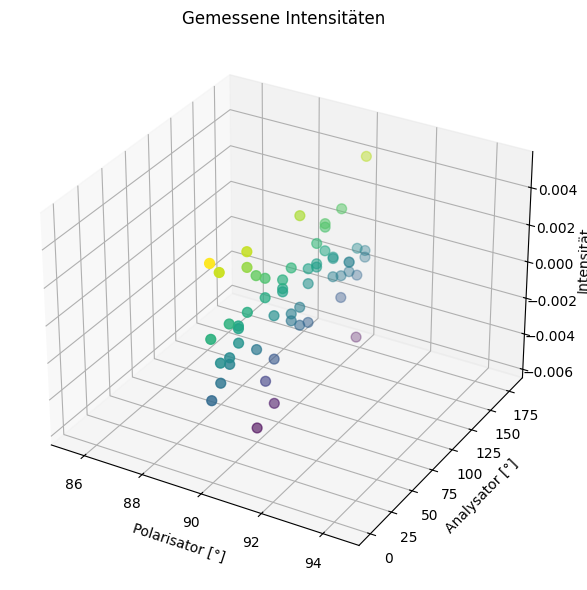


Rekonstruierte 3x3-Matrix:
[[-1.76352104e-04  1.76352104e-04  8.84600331e-20]
 [ 2.45704752e-04 -2.45704752e-04  3.00901538e-20]
 [ 1.88462278e-04 -1.88462278e-04  2.30799726e-20]]

Normierte Matrix:
[[ 1.00000000e+00 -1.00000000e+00 -5.01610307e-16]
 [-1.39326238e+00  1.39326238e+00 -1.70625431e-16]
 [-1.06867042e+00  1.06867042e+00 -1.30874382e-16]]
Ursprüngliche Probenmatrix:
[[ 0.8   0.1   0.05  0.02]
 [ 0.08  0.55  0.1   0.03]
 [ 0.04  0.12  0.45 -0.08]
 [ 0.01  0.02  0.1   0.35]]

Rang des Gleichungssystems: 3
Fertig.


In [5]:
# ============================================================
# 12. Hauptprogramm
# ============================================================

if __name__ == "__main__":

    print("=" * 60)
    print("MÜLLER-MATRIX-MESSUNG")
    print("=" * 60)

    print(f"Laserwellenlänge: {WAVELENGTH * 1e9:.0f} nm")

    # --------------------------------------------------------
    # Winkel einstellen
    # --------------------------------------------------------

    # Mehrere Polarisatorstellungen
    polarizer_angles = np.array([90, 90, 90]
    )

    # Mehrere Analysatorstellungen
    analyzer_angles = np.array(
        [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180]
    )

    print(
        f"Polarisatorwinkel: {len(polarizer_angles)}"
    )

    print(
        f"Analysatorwinkel: {len(analyzer_angles)}"
    )

    print(
        f"Anzahl Messungen: "
        f"{len(polarizer_angles) * len(analyzer_angles)}"
    )

    # --------------------------------------------------------
    # Beispiel-Probe
    # --------------------------------------------------------

    M_true = example_sample_matrix()

    print("Ursprüngliche Probenmatrix:")
    print(M_true)

    # --------------------------------------------------------
    # Messungen simulieren
    # --------------------------------------------------------

    measurements = generate_measurements(
        M_true,
        polarizer_angles,
        analyzer_angles,
        noise_std=0.002
    )

    # --------------------------------------------------------
    # Messdaten speichern
    # --------------------------------------------------------

    save_measurements(
        "mueller_measurements.csv",
        measurements
    )

    print(
        "\nMessdaten gespeichert als:"
        " mueller_measurements.csv"
    )

    # --------------------------------------------------------
    # Messdaten darstellen
    # --------------------------------------------------------

    plot_measurements(measurements)

    # --------------------------------------------------------
    # Müller-Matrix rekonstruieren
    # --------------------------------------------------------

    M_reconstructed, residuals, rank = \
        reconstruct_mueller_matrix(measurements)

    print("\nRekonstruierte 3x3-Matrix:")
    print(M_reconstructed)

    # --------------------------------------------------------
    # Normierung
    # --------------------------------------------------------

    M_normalized = normalize_matrix(
        M_reconstructed
    )

    print("\nNormierte Matrix:")
    print(M_normalized)
    print("Ursprüngliche Probenmatrix:")
    print(M_true)

    print("\nRang des Gleichungssystems:", rank)

    if len(residuals) > 0:
        print(
            "Summe der quadratischen Residuen:",
            residuals[0]
        )

    print("Fertig.")


Stokes-Vektor vor der Probe (nach QWP): [0.5 0.  0.  0.5]
Stokes-Vektor nach der Probe:           [ 0.5    -0.2783  0.3317  0.25  ]


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/intensitaet_vs_analysator.png'

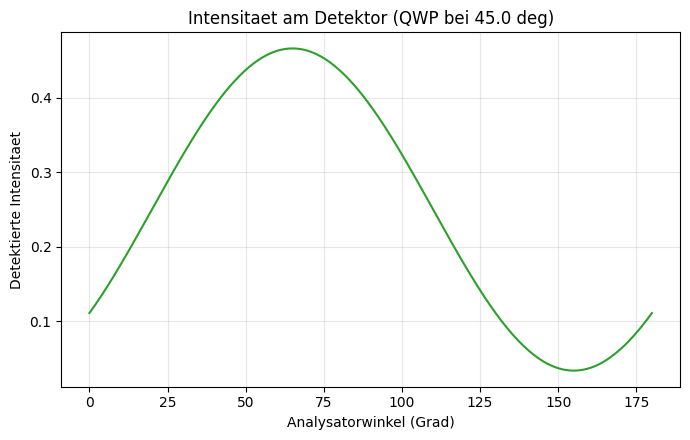

In [9]:
"""
Mueller-Polarimetrie Simulation
================================

Aufbau:
    Grüner Laser -> fester Polarisator (0 Grad) -> lambda/4-Plaettchen (Winkel frei waehlbar)
    -> Probe (beliebige Mueller-Matrix) -> variabler Polarisator (Analysator)

Konventionen:
    - Stokes-Vektor S = (S0, S1, S2, S3)
        S0 = Gesamtintensitaet
        S1 = horizontal(+)/vertikal(-) linear polarisierter Anteil
        S2 = +45 grad/-45 grad linear polarisierter Anteil
        S3 = rechts(+)/links(-) zirkular polarisierter Anteil
    - Winkel in Radiant intern, Eingaben in Grad
    - Mueller-Matrizen nach der ueblichen Definition (siehe z.B. Goldstein,
      "Polarized Light")

Physikalische Einschraenkung des Aufbaus:
    Ein linearer Analysator am Ausgang misst nur

        I(theta_a) = 0.5 * (S0 + S1*cos(2 theta_a) + S2*sin(2 theta_a))

    Das heisst: S3 (zirkularer Anteil) NACH der Probe ist mit diesem Aufbau
    NICHT messbar. Fuer eine vollstaendige 4x4 Mueller-Matrix-Rekonstruktion
    der Probe braeuchte man zusaetzlich ein zweites lambda/4-Plaettchen VOR
    dem Analysator (klassischer "dual rotating retarder" Polarimeter-Aufbau).
    Das wird im Code unten explizit sichtbar gemacht.
"""

import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# Grundbausteine der Mueller-Rechnung
# ----------------------------------------------------------------------

def deg2rad(deg):
    return np.deg2rad(deg)


def mueller_rotation(theta_rad):
    """Rotationsmatrix im Mueller-Formalismus (dreht das Bezugssystem)."""
    c2 = np.cos(2 * theta_rad)
    s2 = np.sin(2 * theta_rad)
    return np.array([
        [1, 0,   0,  0],
        [0, c2,  s2, 0],
        [0, -s2, c2, 0],
        [0, 0,   0,  1],
    ])


def mueller_linear_polarizer(theta_deg, Tmax=1.0, Tmin=0.0):
    """
    Linearer Polarisator mit Durchlassachse bei theta_deg.
    Tmax/Tmin erlauben einen nicht-idealen (realen) Polarisator.
    """
    theta = deg2rad(theta_deg)
    A = 0.5 * (Tmax + Tmin)
    B = 0.5 * (Tmax - Tmin)
    C = np.sqrt(Tmax * Tmin)
    M0 = np.array([
        [A, B, 0, 0],
        [B, A, 0, 0],
        [0, 0, C, 0],
        [0, 0, 0, C],
    ])
    R = mueller_rotation(theta)
    Rm = mueller_rotation(-theta)
    return Rm @ M0 @ R


def mueller_retarder(theta_deg, delta_deg):
    """
    Allgemeine Verzoegerungsplatte (Waveplate) mit schneller Achse bei
    theta_deg und Phasenverzoegerung delta_deg.
    delta = 90 grad  -> lambda/4-Plaettchen
    delta = 180 grad -> lambda/2-Plaettchen
    """
    theta = deg2rad(theta_deg)
    delta = deg2rad(delta_deg)
    c = np.cos(delta)
    s = np.sin(delta)
    M0 = np.array([
        [1, 0, 0,  0],
        [0, 1, 0,  0],
        [0, 0, c,  s],
        [0, 0, -s, c],
    ])
    R = mueller_rotation(theta)
    Rm = mueller_rotation(-theta)
    return Rm @ M0 @ R


def mueller_depolarizer(d1=1.0, d2=1.0, d3=1.0):
    """Idealer Depolarisator: reduziert S1,S2,S3 um Faktoren d1,d2,d3 <= 1."""
    return np.diag([1.0, d1, d2, d3])


def mueller_optical_rotator(alpha_deg):
    """
    Optisch aktives Medium (z.B. Zuckerloesung): dreht die lineare
    Polarisationsebene um alpha_deg, ohne die Elliptizitaet zu aendern.
    Formal identisch zur Mueller-Rotationsmatrix.
    """
    return mueller_rotation(deg2rad(alpha_deg))


# ----------------------------------------------------------------------
# Beispiel-Proben (frei anpassbar / kombinierbar)
# ----------------------------------------------------------------------

def probe_identitaet():
    return np.eye(4)


def probe_linearer_diattenuator(theta_deg=30, Tmax=1.0, Tmin=0.3):
    """z.B. leicht dichroitische Probe."""
    return mueller_linear_polarizer(theta_deg, Tmax, Tmin)


def probe_verzoegerungsplatte(theta_deg=20, delta_deg=60):
    """z.B. spannungsdoppelbrechende Probe / Kristall."""
    return mueller_retarder(theta_deg, delta_deg)


def probe_optisch_aktiv_plus_depol(alpha_deg=25, d=0.9):
    """z.B. Zuckerloesung mit leichter Streuung/Depolarisation."""
    return mueller_depolarizer(d, d, d) @ mueller_optical_rotator(alpha_deg)


# ----------------------------------------------------------------------
# Optischer Aufbau: Quelle -> fester Polarisator -> QWP -> Probe -> Analysator
# ----------------------------------------------------------------------

def eingangszustand(I0, fester_polarisator_deg, qwp_winkel_deg):
    """
    Stokes-Vektor direkt nach dem lambda/4-Plaettchen, also der Zustand,
    der auf die Probe trifft (Polarization State Generator, PSG).
    """
    S_quelle = np.array([I0, 0, 0, 0])  # unpolarisierter gruener Laser
    M_pol = mueller_linear_polarizer(fester_polarisator_deg)
    M_qwp = mueller_retarder(qwp_winkel_deg, 90.0)
    return M_qwp @ M_pol @ S_quelle


def intensitaet_am_detektor(S_vor_analysator, analysator_deg):
    """Intensitaet nach dem variablen Analysator (Malus-artig, verallgemeinert)."""
    M_an = mueller_linear_polarizer(analysator_deg)
    S_out = M_an @ S_vor_analysator
    return S_out[0]


def simuliere_kurve(I0, fester_polarisator_deg, qwp_winkel_deg, M_probe,
                     analysator_winkel_liste_deg):
    S_ein = eingangszustand(I0, fester_polarisator_deg, qwp_winkel_deg)
    S_nach_probe = M_probe @ S_ein
    I = np.array([
        intensitaet_am_detektor(S_nach_probe, a)
        for a in analysator_winkel_liste_deg
    ])
    return I, S_ein, S_nach_probe


# ----------------------------------------------------------------------
# Teil-Rekonstruktion von S0, S1, S2 nach der Probe (S3 nicht zugaenglich!)
# ----------------------------------------------------------------------

def rekonstruiere_S0_S1_S2(analysator_winkel_deg, I_gemessen):
    """
    Fit von I(theta_a) = A + B*cos(2 theta_a) + C*sin(2 theta_a)
    liefert S0 = 2A, S1 = 2B, S2 = 2C.
    S3 kann mit einem einzelnen linearen Analysator NICHT bestimmt werden.
    """
    theta = deg2rad(np.asarray(analysator_winkel_deg))
    X = np.column_stack([
        np.ones_like(theta),
        np.cos(2 * theta),
        np.sin(2 * theta),
    ])
    coeffs, *_ = np.linalg.lstsq(X, I_gemessen, rcond=None)
    A, B, C = coeffs
    return np.array([2 * A, 2 * B, 2 * C])  # S0, S1, S2


# ----------------------------------------------------------------------
# Demo / Hauptprogramm
# ----------------------------------------------------------------------

if __name__ == "__main__":

    I0 = 1.0
    FESTER_POLARISATOR = 0.0      # Grad
    QWP_WINKEL = 45.0             # Grad, erzeugt bei 45 grad zirkulare Pol.

    # Probe auswaehlen (einfach eine der Beispielfunktionen nutzen):
    M_probe = probe_verzoegerungsplatte(theta_deg=20, delta_deg=60)
    # Alternativen zum Ausprobieren:
    # M_probe = probe_identitaet()
    # M_probe = probe_linearer_diattenuator(theta_deg=30, Tmax=1.0, Tmin=0.3)
    # M_probe = probe_optisch_aktiv_plus_depol(alpha_deg=25, d=0.9)

    analysator_winkel = np.linspace(0, 180, 361)

    I_signal, S_ein, S_nach_probe = simuliere_kurve(
        I0, FESTER_POLARISATOR, QWP_WINKEL, M_probe, analysator_winkel
    )

    print("Stokes-Vektor vor der Probe (nach QWP):", np.round(S_ein, 4))
    print("Stokes-Vektor nach der Probe:          ", np.round(S_nach_probe, 4))

    # --- Plot 1: gemessene Intensitaet vs. Analysatorwinkel -----------
    fig1, ax1 = plt.subplots(figsize=(7, 4.5))
    ax1.plot(analysator_winkel, I_signal, color="tab:green")
    ax1.set_xlabel("Analysatorwinkel (Grad)")
    ax1.set_ylabel("Detektierte Intensitaet")
    ax1.set_title(f"Intensitaet am Detektor (QWP bei {QWP_WINKEL} deg)")
    ax1.grid(alpha=0.3)
    fig1.tight_layout()
    fig1.savefig("/mnt/user-data/outputs/intensitaet_vs_analysator.png", dpi=150)

    # --- Rekonstruktion S0,S1,S2 aus der Kurve prüfen ------------------
    S_rek = rekonstruiere_S0_S1_S2(analysator_winkel, I_signal)
    print("\nAus der Analysator-Kurve rekonstruiert (S3 nicht bestimmbar):")
    print("  S0, S1, S2 (rekonstruiert):", np.round(S_rek, 4))
    print("  S0, S1, S2 (exakt, Simulation):", np.round(S_nach_probe[:3], 4))
    print("  S3 (exakt, aber mit diesem Aufbau NICHT messbar):",
          round(S_nach_probe[3], 4))

    # --- Plot 2: Karte Intensitaet(QWP-Winkel, Analysatorwinkel) ------
    qwp_winkel_liste = np.linspace(0, 180, 91)
    I_map = np.zeros((len(qwp_winkel_liste), len(analysator_winkel)))
    for i, qwp_w in enumerate(qwp_winkel_liste):
        I_map[i, :], _, _ = simuliere_kurve(
            I0, FESTER_POLARISATOR, qwp_w, M_probe, analysator_winkel
        )

    fig2, ax2 = plt.subplots(figsize=(7, 5.5))
    im = ax2.imshow(
        I_map, origin="lower", aspect="auto", cmap="viridis",
        extent=[analysator_winkel.min(), analysator_winkel.max(),
                qwp_winkel_liste.min(), qwp_winkel_liste.max()],
    )
    ax2.set_xlabel("Analysatorwinkel (Grad)")
    ax2.set_ylabel("lambda/4-Plaettchen Winkel (Grad)")
    ax2.set_title("Detektierte Intensitaet als Funktion beider Winkel")
    fig2.colorbar(im, ax=ax2, label="Intensitaet")
    fig2.tight_layout()
    fig2.savefig("/mnt/user-data/outputs/intensitaetskarte.png", dpi=150)

    print("\nPlots gespeichert:")
    print("  intensitaet_vs_analysator.png")
    print("  intensitaetskarte.png")
